# 🧠 Session 1: Introduction to Machine Learning in Neuroimaging

In neuroimaging, machine learning is not just about training a model and reporting accuracy.  
The quality of the final model depends heavily on how well we understand the data **before modeling**.

This notebook focuses on the most important first phase of any ML project:

- understanding the dataset
- identifying potential problems
- visualizing patterns
- cleaning the data carefully
- preparing features and labels correctly

These steps are essential because neuroimaging datasets are often:
- high-dimensional
- noisy
- heterogeneous
- affected by confounds
- partially incomplete
- collected from clinically diverse populations

If we skip careful exploration and preprocessing, even sophisticated models can produce misleading results.

---

## 🎯 Why this session is important for future ML work

Everything we do here directly affects future models such as:

- **Logistic Regression**
- **Support Vector Machines (SVM)**
- **Random Forest**
- **XGBoost**
- **Neural Networks**

For example:
- missing values can break many algorithms
- unscaled features can distort distance-based or linear models
- inconsistent labels can corrupt training targets
- leakage can create falsely high performance
- outliers can bias coefficients and decision boundaries
- confounds can make the model learn the wrong signal

So this notebook is not “just EDA” — it is the foundation of trustworthy machine learning.


# 📦 Importing the libraries

Before starting analysis, we load the core Python libraries used in data science and machine learning.

### Why this step matters

Each library plays a different role:

- **pandas** → for loading and manipulating tabular data
- **numpy** → for numerical operations
- **matplotlib / seaborn** → for visualization
- **scikit-learn** → for preprocessing, splitting, and machine learning pipelines


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

sns.set(style="whitegrid", context="talk", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)


# 🧭 Machine Learning Workflow in Neuroimaging

A typical neuroimaging ML pipeline looks like this:

1. **Define the question**
   - Example: Can diffusion MRI features help distinguish AD, MCI, and controls?

2. **Collect and organize the data**
   - Imaging-derived features
   - Demographics / clinical variables
   - Labels such as diagnosis

3. **Preprocess the data**
   - handle missing values
   - normalize feature scales
   - encode labels
   - remove leakage-prone columns

4. **Explore the data**
   - inspect distributions
   - check class balance
   - identify outliers
   - assess feature correlations

5. **Split the data**
   - train / validation / test
   - avoid leakage

6. **Train a model**
   - logistic regression, SVM, random forest, etc.

7. **Evaluate performance**
   - accuracy, F1-score, ROC-AUC
   - confusion matrix
   - cross-validation

8. **Interpret results**
   - feature importance
   - clinical relevance
   - limitations and bias


### Why this step matters

Students often focus immediately on model training, but in real biomedical data analysis, most of the effort happens **before** fitting a model.

This is especially true in neuroimaging because:
- imaging features can be strongly correlated
- biological signals are subtle
- confounds are common
- sample sizes are often limited
- label quality may vary

### Why this is important:

A model is only as good as the pipeline behind it.  
A well-structured workflow ensures that:
- the model learns clinically meaningful signal
- evaluation is fair
- preprocessing is applied correctly
- results can be reproduced in later sessions or publications



# 📂 Load the dMRI dataset

We will use the dataset stored at:

`F:\dmri\ML in Neuroimaging\S1\dMRI_Data.csv`

This file contains diffusion MRI-derived features, tract-related measures,
volumetric markers, age, and diagnosis labels.


In [2]:
data_path = r"F:\dmri\ML in Neuroimaging\S1\dMRI_Data.csv"

df = pd.read_csv(data_path)
df.head()


,subject_id,FA_mean,MD_mean,FD_fixel,FC_fixel,age,diagnosis,RD_mean,AD_mean,MK_mean,...,Thalamus_Vol,WMH_load,FD_ANT,FC_ANT,FD_CST,FC_CST,StreamlineCount_CST,StreamlineCount_CCG,PSMD,gFA
0,sub-001,0.573375,0.000516,1.297914,1.178836,62,MCI,0.000318,0.001353,0.907894,...,7369.766860,778.530385,0.718605,1.099945,0.808100,0.994400,6485.0,6062.0,0.000387,1.399097
1,sub-002,0.400416,0.000866,0.895970,0.998504,83,MCI,0.000327,0.001105,0.787403,...,9417.291498,852.533604,0.565109,1.324354,0.502839,1.236485,10745.0,11710.0,0.000538,0.620830
2,sub-003,0.415751,0.000955,1.415090,0.952207,62,AD,0.000225,0.001233,1.057879,...,7027.726944,2455.838722,0.840730,0.996108,0.990741,0.880322,19461.0,5070.0,0.000444,-0.617796
3,sub-004,0.473586,0.000929,1.033029,0.865214,80,Control,0.000393,0.001695,0.804308,...,7937.516371,705.230561,0.488594,0.876969,0.523818,0.892258,18913.0,7257.0,0.000444,NaN
4,sub-005,0.446340,0.000982,0.657955,1.114482,84,ad,0.000536,0.001724,0.586458,...,7523.231630,784.607902,0.631081,0.841068,0.903319,1.159767,7620.0,13868.0,0.000319,-0.727465


# 👀 First look at the dataset

After loading the data, we inspect its shape, column names, and general structure.

### Why this step matters

This gives us an immediate overview of:
- how many samples we have
- how many features are available
- whether the dataset is small or moderate in size
- whether the columns seem clinically meaningful
- whether there are possible ID or label columns

For this dataset, we already expect:
- `subject_id` to be an identifier
- `diagnosis` to be the target label
- the remaining columns to be candidate predictors

### Why this is important for future ML models

The number of samples and features influences nearly every modeling decision:
- train/test split strategy
- model complexity
- risk of overfitting
- need for feature selection
- interpretability of the final model

For example:
- a dataset with many features and few subjects may require regularization
- a multiclass diagnosis target may require different evaluation metrics than a binary task


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.info()


Shape of dataset: (521, 28)

Columns:
['subject_id', 'FA_mean', 'MD_mean', 'FD_fixel', 'FC_fixel', 'age', 'diagnosis', 'RD_mean', 'AD_mean', 'MK_mean', 'ODI', 'ODI.1', 'NDI', 'TBSS_FA', 'TBSS_MD', 'TractVol_CST', 'TractVol_CCG', 'Hippocampus_Vol', 'Thalamus_Vol', 'WMH_load', 'FD_ANT', 'FC_ANT', 'FD_CST', 'FC_CST', 'StreamlineCount_CST', 'StreamlineCount_CCG', 'PSMD', 'gFA']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subject_id           521 non-null    object 
 1   FA_mean              501 non-null    float64
 2   MD_mean              521 non-null    float64
 3   FD_fixel             521 non-null    float64
 4   FC_fixel             521 non-null    float64
 5   age                  521 non-null    int64  
 6   diagnosis            520 non-null    object 
 7   RD_mean              516 non-null    float64
 8   AD_mean      

## 🔍 What do we expect?

From an initial inspection, we already know:
- there are **521 samples**
- there are **28 columns**
- `subject_id` is likely an **identifier**
- `diagnosis` is likely the **target label**
- most other columns are **numerical imaging features**


# 📋 Previewing the data and summary statistics

Looking at the first few rows helps us understand what individual records look like.  
Summary statistics help us inspect the numerical ranges and spread of each feature.

### Why this step matters

This step helps answer questions such as:
- Are the values plausible?
- Are some variables measured on very different scales?
- Are there unusual minimum or maximum values?
- Are some columns dominated by missing values?
- Are some variables nearly constant?

In neuroimaging, this is especially useful because different modalities and derived metrics often have very different numeric scales.

### Why this is important for future ML models

Feature scale matters a lot in machine learning.

For example:
- linear models and SVMs are sensitive to magnitude differences
- large-scale variables may dominate optimization
- near-constant variables may add noise rather than signal
- implausible values may indicate preprocessing or extraction errors

So summary statistics are not just descriptive — they guide preprocessing choices.


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject_id,521,500,sub-010,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FA_mean,501.0,NaN,NaN,NaN,0.403804,0.111142,0.201038,0.311035,0.412506,0.495964,0.599077
MD_mean,521.0,NaN,NaN,NaN,0.000717,0.000211,-0.0001,0.000616,0.00075,0.000853,0.000998
FD_fixel,521.0,NaN,NaN,NaN,1.157915,0.819026,0.500135,0.781004,1.021446,1.294211,5.0
FC_fixel,521.0,NaN,NaN,NaN,0.999085,0.113556,0.800797,0.899983,1.007203,1.09296,1.199557
age,521.0,NaN,NaN,NaN,67.364683,16.598118,-5.0,62.0,70.0,77.0,84.0
diagnosis,520,7,Control,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RD_mean,516.0,NaN,NaN,NaN,0.000496,0.00017,0.000204,0.000359,0.00049,0.000636,0.000799
AD_mean,516.0,NaN,NaN,NaN,0.001396,0.000236,0.001001,0.001189,0.001401,0.001585,0.0018
MK_mean,516.0,NaN,NaN,NaN,0.995268,0.290294,0.500241,0.741661,0.98211,1.26642,1.499207


In [5]:
df['diagnosis'].value_counts()

diagnosis
Control    226
MCI        183
AD          90
ad          11
control      7
mci          2
cn           1
Name: count, dtype: int64

# 🧹 Cleaning diagnosis labels

The diagnosis labels appear to have inconsistent formatting, such as:
- `AD`
- `ad`
- `Control`
- `control`

### Why this step matters

Machine learning models treat different strings as different classes.  
That means:
- `AD` and `ad` would be interpreted as separate labels
- `Control` and `control` would also be treated as separate labels

This creates an artificial class fragmentation problem.

### Why this is important for future ML models

The target label is the variable we want the model to predict.  
If the target is inconsistent:
- the model may learn from incorrect class definitions
- class counts become inaccurate
- evaluation metrics become misleading
- stratified train/test splitting may fail or behave poorly

Cleaning labels is therefore one of the most important early steps in supervised learning.


In [6]:
df["diagnosis"] = df["diagnosis"].astype(str).str.strip().str.lower()

label_mapping = {
    "ad": "AD",
    "mci": "MCI",
    "control": "Control",
    "cn": "Control",
    "nan": np.nan
}

df["diagnosis"] = df["diagnosis"].map(label_mapping)
df["diagnosis"].value_counts(dropna=False)


diagnosis
Control    234
MCI        185
AD         101
NaN          1
Name: count, dtype: int64

In [7]:
df['subject_id'].value_counts()

subject_id
sub-010    3
sub-375    2
sub-125    2
sub-407    2
sub-105    2
          ..
sub-168    1
sub-167    1
sub-166    1
sub-165    1
sub-500    1
Name: count, Length: 500, dtype: int64

In [8]:
# Count fully duplicated rows (all columns identical)
exact_dupes = df.duplicated().sum()
print(f"Number of fully duplicated rows: {exact_dupes}")

# Count rows where only subject_id is duplicated
id_dupes = df.duplicated(subset=['subject_id']).sum()
print(f"Number of rows with duplicated subject_id: {id_dupes}")

# View the duplicated subject_ids along with their frequency
dup_ids = df['subject_id'].value_counts()
dup_ids = dup_ids[dup_ids >= 2]
print(dup_ids)

# Display rows belonging to duplicated IDs for visual inspection
df[df['subject_id'].isin(dup_ids.index)].sort_values('subject_id')


Number of fully duplicated rows: 1
Number of rows with duplicated subject_id: 21
subject_id
sub-010    3
sub-375    2
sub-125    2
sub-407    2
sub-105    2
sub-031    2
sub-156    2
sub-451    2
sub-395    2
sub-085    2
sub-389    2
sub-362    2
sub-409    2
sub-496    2
sub-372    2
sub-195    2
sub-069    2
sub-317    2
sub-074    2
sub-378    2
Name: count, dtype: int64


,subject_id,FA_mean,MD_mean,FD_fixel,FC_fixel,age,diagnosis,RD_mean,AD_mean,MK_mean,...,Thalamus_Vol,WMH_load,FD_ANT,FC_ANT,FD_CST,FC_CST,StreamlineCount_CST,StreamlineCount_CCG,PSMD,gFA
9,sub-010,0.520380,0.000862,1.406143,0.804567,70,MCI,0.000632,0.001065,1.499207,...,8958.067118,54.024886,0.925435,1.030428,0.715774,1.059304,7673.0,14727.0,0.000307,-0.097167
10,sub-010,0.520380,0.000862,1.406143,0.804567,70,MCI,0.000632,0.001065,1.499207,...,8958.067118,54.024886,0.925435,1.030428,0.715774,1.059304,7673.0,14727.0,0.000307,-0.097167
511,sub-010,NaN,0.000828,1.206976,0.995398,75,AD,0.000517,0.001354,0.944480,...,7239.493200,1950.527353,0.876256,1.326549,0.687197,0.987811,19600.0,10739.0,0.000527,0.451700
31,sub-031,0.398415,0.000501,1.381928,0.916018,71,Control,0.000574,0.001306,0.554745,...,9212.468453,175.017668,0.988558,0.849643,1.124834,0.994456,7386.0,3667.0,0.000344,0.593105
518,sub-031,0.241193,-0.000100,0.601892,1.037136,-5,AD,0.000280,0.001637,0.691490,...,8232.529532,521.782623,0.777550,0.847536,0.843405,1.353343,16680.0,14063.0,0.000316,1.547641
69,sub-069,0.421481,0.000679,1.134142,0.972808,74,MCI,0.000702,0.001594,1.432504,...,8037.917463,1961.996987,0.514637,1.131722,1.123491,1.312693,19805.0,14457.0,0.000373,1.733441
509,sub-069,0.534626,0.000610,0.546852,1.184368,68,AD,0.000588,0.001507,0.543881,...,7146.524870,2387.641399,1.156939,1.176159,0.786658,0.907493,18766.0,14476.0,0.000526,1.722267
74,sub-074,0.572372,0.000911,0.569641,1.188271,62,Control,0.000237,0.001499,1.475245,...,8963.754401,1341.548548,0.983283,1.173726,1.126939,1.451547,NaN,5249.0,0.000485,0.667383
502,sub-074,0.358927,0.000633,0.633828,0.867891,83,Control,0.000666,0.001407,1.353396,...,7679.661546,213.162906,0.594757,1.368777,0.687925,1.265181,18085.0,-4198.0,0.000487,-1.408984
514,sub-085,0.413782,0.000896,0.503820,1.029043,80,MCI,0.000249,0.001355,1.169953,...,8885.009096,775.282859,1.103766,0.963690,0.877314,1.261556,6857.0,8834.0,0.000309,0.758066


In [9]:
# Drop duplicate rows and keep only one copy
df = df.drop_duplicates().reset_index(drop=True)

# Keep the first occurrence of each subject_id
df = df.drop_duplicates(subset=['subject_id'], keep='first').reset_index(drop=True)
# Or use keep='last'


In [10]:
# Count fully duplicated rows (all columns identical)
exact_dupes = df.duplicated().sum()
print(f"Number of fully duplicated rows: {exact_dupes}")

# Count rows where only subject_id is duplicated
id_dupes = df.duplicated(subset=['subject_id']).sum()
print(f"Number of rows with duplicated subject_id: {id_dupes}")

# View the duplicated subject_ids along with their frequency
dup_ids = df['subject_id'].value_counts()
dup_ids = dup_ids[dup_ids >= 2]
print(dup_ids)

# Display rows belonging to duplicated IDs for visual inspection
df[df['subject_id'].isin(dup_ids.index)].sort_values('subject_id')


Number of fully duplicated rows: 0
Number of rows with duplicated subject_id: 0
Series([], Name: count, dtype: int64)


,subject_id,FA_mean,MD_mean,FD_fixel,FC_fixel,age,diagnosis,RD_mean,AD_mean,MK_mean,...,Thalamus_Vol,WMH_load,FD_ANT,FC_ANT,FD_CST,FC_CST,StreamlineCount_CST,StreamlineCount_CCG,PSMD,gFA


In [11]:
df.shape

(500, 28)

In [12]:
# Statistical summary of the age column
print(df['age'].describe())

# Count negative or zero ages (biologically impossible)
invalid_age = df[df['age'] <= 0]
print(f"Number of invalid (<= 0) age values: {len(invalid_age)}")
print(invalid_age[['subject_id', 'age', 'diagnosis']])

# Check for unrealistically high ages as well (optional sanity check)
print(df[df['age'] > 120][['subject_id', 'age']])


count    500.000000
mean      67.328000
std       16.545208
min       -5.000000
25%       62.000000
50%       70.000000
75%       77.000000
max       84.000000
Name: age, dtype: float64
Number of invalid (<= 0) age values: 19
    subject_id  age diagnosis
22     sub-023   -5   Control
32     sub-033   -5        AD
34     sub-035   -5       MCI
104    sub-105   -5   Control
122    sub-123   -5   Control
253    sub-254   -5   Control
262    sub-263   -5   Control
294    sub-295   -5   Control
301    sub-302   -5   Control
315    sub-316   -5        AD
340    sub-341   -5   Control
342    sub-343   -5   Control
382    sub-383   -5   Control
392    sub-393   -5        AD
394    sub-395   -5   Control
429    sub-430   -5       MCI
459    sub-460   -5       MCI
463    sub-464   -5       MCI
491    sub-492   -5        AD
Empty DataFrame
Columns: [subject_id, age]
Index: []


In [13]:
# Replace any non-positive age with NaN
df.loc[df['age'] <= 0, 'age'] = np.nan
print(f"Missing ages after cleanup: {df['age'].isna().sum()}")

Missing ages after cleanup: 19


In [14]:
# Group-wise median imputation by diagnosis
df['age'] = df.groupby('diagnosis')['age'].transform(
    lambda x: x.fillna(x.median())
)

# Statistical summary of the age column
print(df['age'].describe())

# Count negative or zero ages (biologically impossible)
invalid_age = df[df['age'] <= 0]
print(f"Number of invalid (<= 0) age values: {len(invalid_age)}")
print(invalid_age[['subject_id', 'age', 'diagnosis']])

# Check for unrealistically high ages as well (optional sanity check)
#print(df[df['age'] > 120][['subject_id', 'age']])


count    499.000000
mean      70.213427
std        8.174063
min       55.000000
25%       63.000000
50%       71.000000
75%       77.000000
max       84.000000
Name: age, dtype: float64
Number of invalid (<= 0) age values: 0
Empty DataFrame
Columns: [subject_id, age, diagnosis]
Index: []


# 🧬 Identifying numerical and categorical columns

Before preprocessing, we need to know which columns are:
- numerical
- categorical
- identifiers
- targets

### Why this step matters

Different data types require different handling:
- numerical variables may need scaling or imputation
- categorical variables may need encoding
- identifier columns should usually be removed
- target columns must be separated from predictors

### Why this is important for future ML models

Most machine learning models in `scikit-learn` expect numeric input arrays.  
If we do not correctly identify data types:
- preprocessing may be applied incorrectly
- the model may crash
- categorical values may be mishandled
- identifiers may accidentally be used as predictive features

For example, using `subject_id` as a predictor could allow the model to memorize subject-specific patterns rather than learning a meaningful biological rule.


In [15]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumerical columns:", numerical_cols)


Categorical columns: ['subject_id', 'diagnosis']

Numerical columns: ['FA_mean', 'MD_mean', 'FD_fixel', 'FC_fixel', 'age', 'RD_mean', 'AD_mean', 'MK_mean', 'ODI', 'ODI.1', 'NDI', 'TBSS_FA', 'TBSS_MD', 'TractVol_CST', 'TractVol_CCG', 'Hippocampus_Vol', 'Thalamus_Vol', 'WMH_load', 'FD_ANT', 'FC_ANT', 'FD_CST', 'FC_CST', 'StreamlineCount_CST', 'StreamlineCount_CCG', 'PSMD', 'gFA']


Typically:
- **categorical**: `subject_id`, `diagnosis`
- **numerical**: all MRI-derived metrics and age


# 🕳️ Missing values analysis

Missing data is common in biomedical and neuroimaging datasets.  
A value may be missing because of:
- acquisition failure
- preprocessing failure
- poor image quality
- segmentation issues
- incomplete clinical metadata

### Why this step matters

We need to know:
- which columns contain missing values
- how much data is missing
- whether missingness is rare or substantial
- whether the target variable is missing
- whether missingness may bias the analysis

Missingness is not just a technical issue — it may also reflect a systematic pattern in the data.

### Why this is important for future ML models

Most machine learning models cannot directly handle NaN values.  
If we ignore missingness:
- training may fail
- data may be dropped in a biased way
- important subjects may be lost
- model estimates may become unstable

This step helps us decide whether to:
- drop rows
- drop features
- impute values
- use more advanced missing-data approaches later

⚠️ Most importantly, imputation must be fit on the training data only, otherwise we risk data leakage.


In [16]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percent": missing_percent
})
missing_df[missing_df["Missing Count"] > 0]


,Missing Count,Missing Percent
FA_mean,18,3.6
TBSS_MD,5,1.0
NDI,5,1.0
StreamlineCount_CCG,5,1.0
StreamlineCount_CST,5,1.0
FC_CST,5,1.0
FD_CST,5,1.0
FD_ANT,5,1.0
Thalamus_Vol,5,1.0
Hippocampus_Vol,5,1.0


In [17]:
# Identify columns with exactly 5 missing values
cols_5_missing = missing_df[missing_df["Missing Count"] == 5].index.tolist()

# Check whether the SAME rows are missing across these columns
overlap = df[df[cols_5_missing].isnull().any(axis=1)]
print(f"Rows with at least one missing among the 5-missing features: {len(overlap)}")
print(overlap['subject_id'].tolist())


Rows with at least one missing among the 5-missing features: 72
['sub-004', 'sub-006', 'sub-016', 'sub-019', 'sub-021', 'sub-023', 'sub-028', 'sub-048', 'sub-050', 'sub-066', 'sub-074', 'sub-075', 'sub-088', 'sub-091', 'sub-093', 'sub-095', 'sub-096', 'sub-101', 'sub-121', 'sub-123', 'sub-132', 'sub-142', 'sub-145', 'sub-148', 'sub-157', 'sub-159', 'sub-161', 'sub-164', 'sub-183', 'sub-186', 'sub-195', 'sub-196', 'sub-198', 'sub-199', 'sub-209', 'sub-211', 'sub-214', 'sub-220', 'sub-221', 'sub-226', 'sub-233', 'sub-234', 'sub-247', 'sub-250', 'sub-253', 'sub-256', 'sub-271', 'sub-274', 'sub-285', 'sub-292', 'sub-306', 'sub-324', 'sub-355', 'sub-367', 'sub-373', 'sub-398', 'sub-408', 'sub-411', 'sub-417', 'sub-419', 'sub-420', 'sub-434', 'sub-446', 'sub-456', 'sub-464', 'sub-465', 'sub-470', 'sub-471', 'sub-477', 'sub-484', 'sub-489', 'sub-492']


In [18]:
na_age = df[df['age'].isna()]
na_age[['subject_id', 'age', 'diagnosis']]

,subject_id,age,diagnosis
12,sub-013,NaN,NaN


In [19]:
df[df['subject_id']=='sub-013']

,subject_id,FA_mean,MD_mean,FD_fixel,FC_fixel,age,diagnosis,RD_mean,AD_mean,MK_mean,...,Thalamus_Vol,WMH_load,FD_ANT,FC_ANT,FD_CST,FC_CST,StreamlineCount_CST,StreamlineCount_CCG,PSMD,gFA
12,sub-013,0.2514,0.000934,0.640712,0.975065,NaN,NaN,0.000355,0.001665,0.659749,...,7741.524234,762.716793,0.928309,1.23112,0.635997,1.492159,12259.0,4966.0,0.000287,0.913071


In [20]:
# Drop rows where the target label is missing
df = df[df['diagnosis'].notna()].reset_index(drop=True)

In [21]:
# Numeric feature columns (exclude IDs and target)
feature_cols = df.select_dtypes(include='number').columns

# Median imputation (compute on training set only )
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())


In [22]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts

subject_id             0
FA_mean                0
PSMD                   0
StreamlineCount_CCG    0
StreamlineCount_CST    0
FC_CST                 0
FD_CST                 0
FC_ANT                 0
FD_ANT                 0
WMH_load               0
Thalamus_Vol           0
Hippocampus_Vol        0
TractVol_CCG           0
TractVol_CST           0
TBSS_MD                0
TBSS_FA                0
NDI                    0
ODI.1                  0
ODI                    0
MK_mean                0
AD_mean                0
RD_mean                0
diagnosis              0
age                    0
FC_fixel               0
FD_fixel               0
MD_mean                0
gFA                    0
dtype: int64

## 💡 Why this matters

Missing data is very common in neuroimaging.

Typical strategies:
- **drop rows** if very few are affected
- **drop columns** if missingness is too high
- **impute values** using mean/median/mode
- use more advanced methods in later sessions

⚠️ Important: imputation must be fit on the **training set only**.


# ⚖️ Examining class distribution

We now inspect how many samples belong to each diagnosis class.

### Why this step matters

Class balance is central in supervised learning.  
If one class is much more common than the others, a model may appear to perform well simply by predicting the majority class.

For example, if 70% of subjects are controls, a naive model could achieve 70% accuracy by predicting "Control" for everyone.

### Why this is important for future ML models

Class imbalance affects:
- choice of performance metrics
- baseline interpretation
- train/test splitting
- model calibration
- class weighting strategies

In later sessions, if the classes are imbalanced, we may need:
- stratified splitting
- balanced accuracy
- macro F1-score
- resampling methods
- class-weighted models

So this plot is essential for interpreting any later classification result correctly.


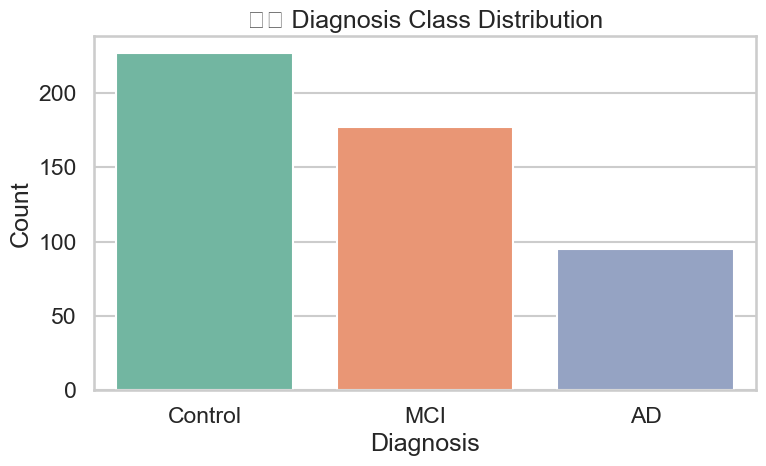

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="diagnosis", order=df["diagnosis"].value_counts(dropna=False).index, palette="Set2")
plt.title("⚖️ Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [24]:
df["diagnosis"].value_counts(dropna=False)


diagnosis
Control    227
MCI        177
AD          95
Name: count, dtype: int64

## ⚠️ Why class balance matters

If one diagnosis group is much larger than the others:
- accuracy can be misleading
- the model may favor the majority class
- stratified splitting becomes important

We will later use **stratified train/test split** when possible.


# 🎂 Age distribution and age by diagnosis

Age is a biologically important variable in neuroimaging and can strongly influence brain measures.

### Why this step matters

Age can affect:
- white matter microstructure
- tract integrity
- brain volume
- lesion burden
- diffusion-derived summary metrics

If age differs substantially across diagnosis groups, then some imaging differences may reflect age rather than disease.

### Why this is important for future ML models

Age is a classic **confound** in neuroimaging ML.

A model trained to predict diagnosis might unintentionally learn:
- “older subjects are more likely to be AD”
instead of
- “this imaging signature reflects disease-related microstructural changes”

This can reduce biological interpretability and limit generalization.

Later, we may:
- include age as a covariate
- residualize age effects
- match age across groups
- test age-balanced analyses


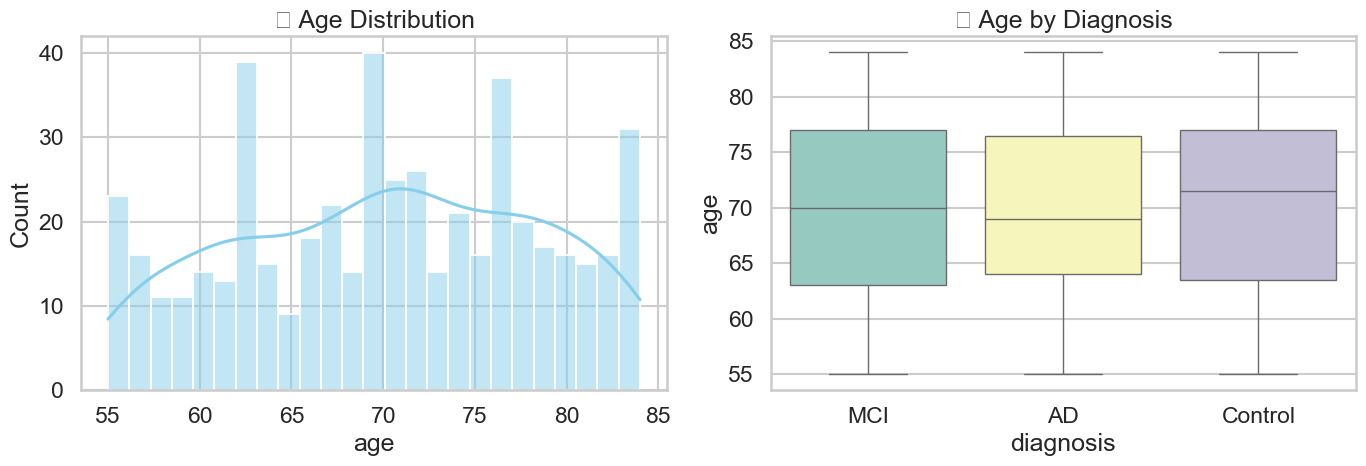

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["age"], kde=True, bins=25, ax=axes[0], color="skyblue")
axes[0].set_title("🎂 Age Distribution")

sns.boxplot(data=df, x="diagnosis", y="age", ax=axes[1], palette="Set3")
axes[1].set_title("🎂 Age by Diagnosis")

plt.tight_layout()
plt.show()


Age is an important variable because it can act as a **confound**.

For example:
- age differences may influence white matter measures
- a model may indirectly learn age instead of disease status


# 📈 Distributions of selected imaging features

We inspect several representative imaging metrics to understand their shape and group differences.

### Why this step matters

Visualizing distributions helps us detect:
- skewed variables
- possible outliers
- heavy tails
- multimodal structure
- diagnosis-related separation

In neuroimaging, many features are not normally distributed, especially lesion-related or count-based measures.

### Why this is important for future ML models

Feature distribution influences:
- whether scaling is sufficient
- whether transformation may be useful
- how sensitive models may be to extreme values
- how separable the classes might be

For example:
- highly skewed variables may benefit from log transformation
- distributions with strong overlap may be harder for simple linear models to separate
- clearly separated boxplots may suggest useful predictive features


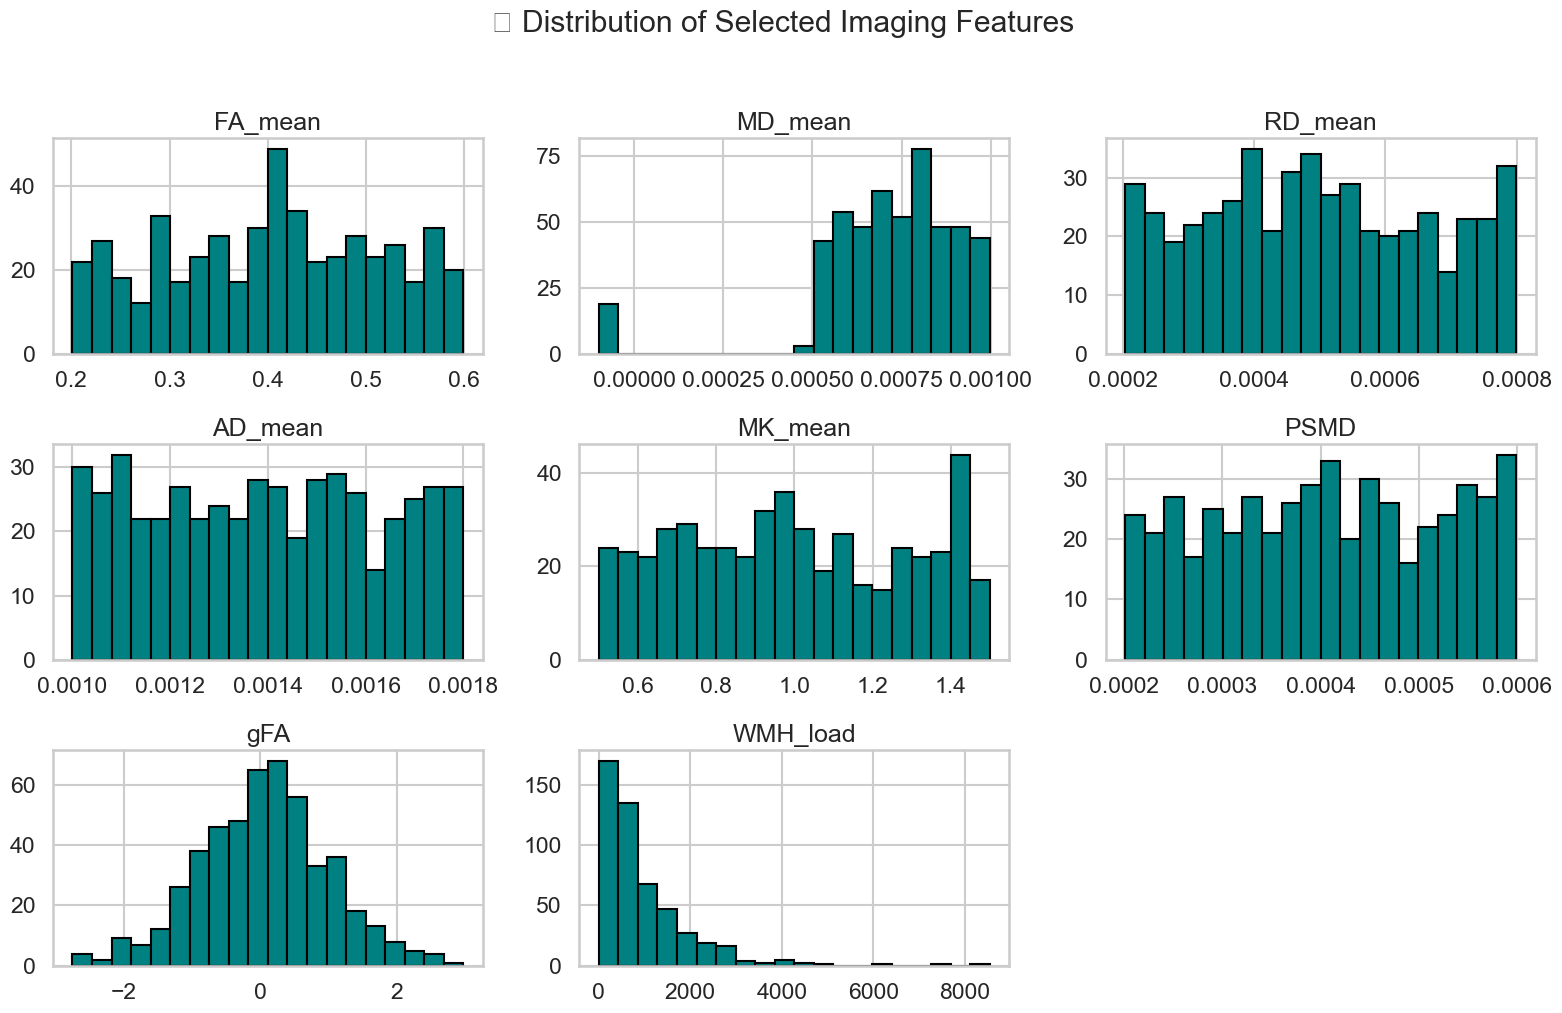

In [26]:
features_to_plot = ["FA_mean", "MD_mean", "RD_mean", "AD_mean", "MK_mean", "PSMD", "gFA", "WMH_load"]

available_features = [col for col in features_to_plot if col in df.columns]

df[available_features].hist(bins=20, figsize=(16, 10), color="teal", edgecolor="black")
plt.suptitle("📊 Distribution of Selected Imaging Features", y=1.02)
plt.tight_layout()
plt.show()


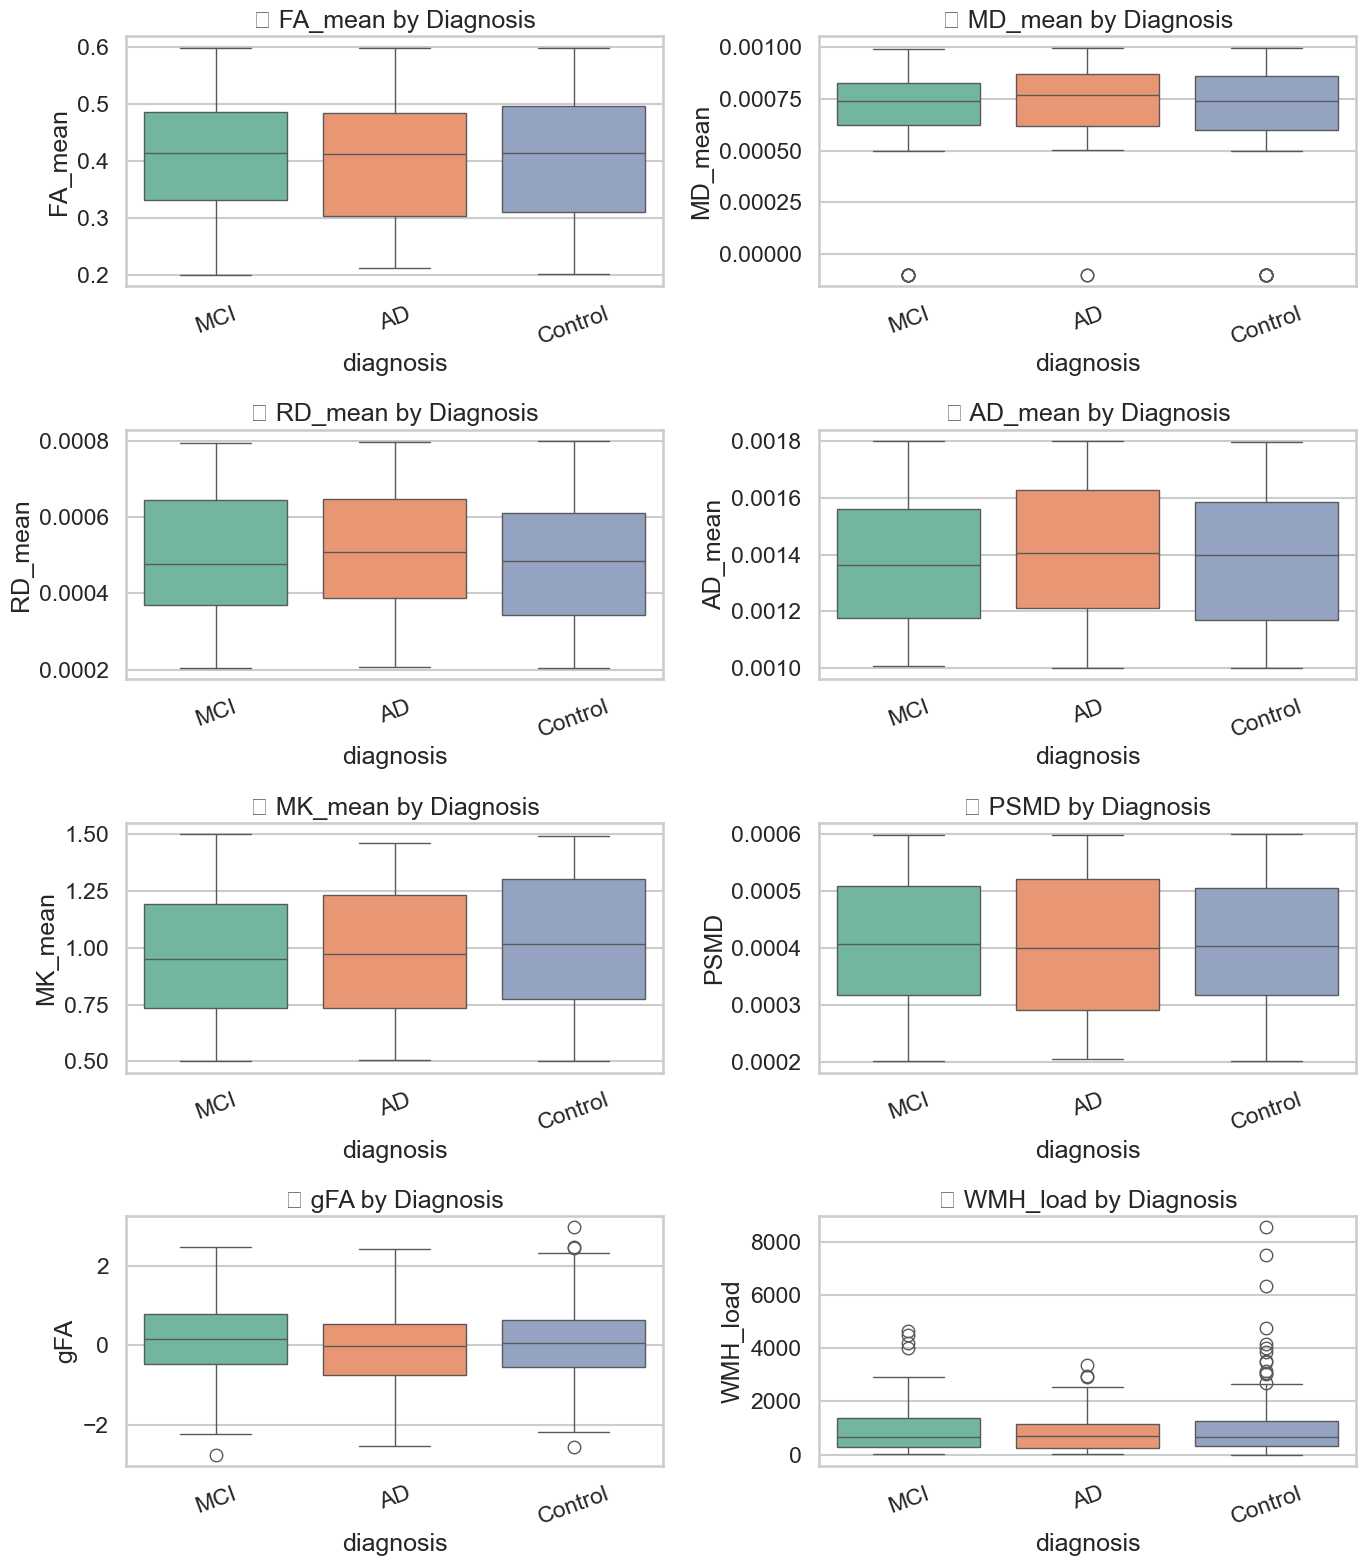

In [27]:
n_cols = 2
n_rows = int(np.ceil(len(available_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    sns.boxplot(data=df, x="diagnosis", y=feature, ax=axes[i], palette="Set2")
    axes[i].set_title(f"📦 {feature} by Diagnosis")
    axes[i].tick_params(axis="x", rotation=20)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# 🚨 Outlier detection

Outliers are observations that differ substantially from the bulk of the data.

### Why this step matters

In neuroimaging, outliers may result from:
- image artifacts
- preprocessing failures
- poor tract segmentation
- scanner-related issues
- true biological extremes

We should not automatically remove outliers.  
Instead, we should identify them and think carefully about their origin.

### Why this is important for future ML models

Outliers can strongly affect:
- linear regression coefficients
- logistic regression boundaries
- distance-based methods like k-NN
- scaling statistics such as mean and standard deviation

They may also:
- inflate variance
- distort class boundaries
- reduce generalization
- produce unstable models

Later, possible strategies may include:
- robust scaling
- transformation
- winsorization
- exclusion after quality control review


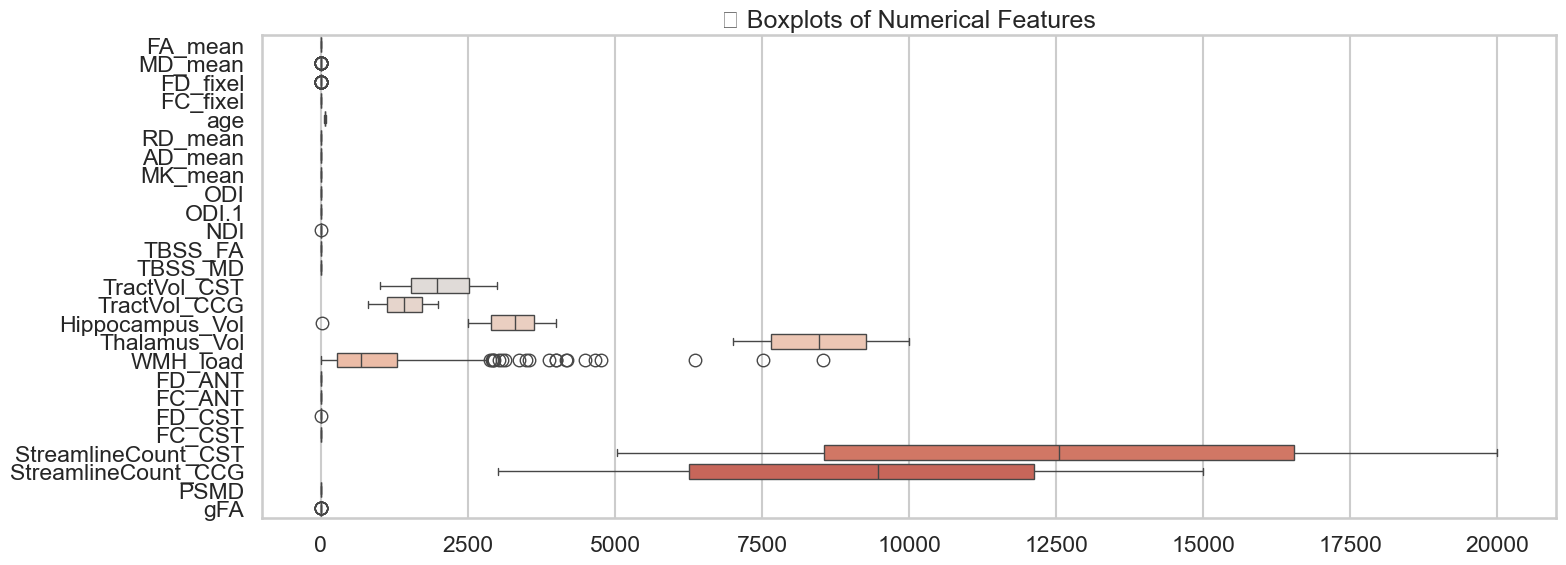

In [28]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df[numerical_cols], orient="h", palette="coolwarm")
plt.title("🚨 Boxplots of Numerical Features")
plt.tight_layout()
plt.show()


In [29]:
def iqr_outlier_summary(dataframe, cols):
    summary = {}
    for col in cols:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_outliers = dataframe[(dataframe[col] < lower) | (dataframe[col] > upper)][col].count()
        summary[col] = n_outliers
    return pd.Series(summary).sort_values(ascending=False)

outlier_counts = iqr_outlier_summary(df, numerical_cols)
outlier_counts.head(15)


WMH_load               21
FD_fixel               20
MD_mean                19
gFA                     8
Hippocampus_Vol         1
FD_CST                  1
NDI                     1
PSMD                    0
StreamlineCount_CCG     0
StreamlineCount_CST     0
FC_CST                  0
FC_ANT                  0
FD_ANT                  0
Thalamus_Vol            0
FA_mean                 0
dtype: int64

In [30]:
# ============================================================
#  DOMAIN BOUNDS — physically-invalid values → NaN
# ============================================================
# Metrics bounded in [0, 1]
bounded_01 = ["FA_mean", "TBSS_FA", "NDI", "ODI", "ODI.1"]

# Metrics that must be strictly non-negative (>= 0)
nonneg = [
    "MD_mean", "RD_mean", "AD_mean", "MK_mean", "TBSS_MD", "PSMD",
    "FD_fixel", "FC_fixel", "FD_ANT", "FC_ANT", "FD_CST", "FC_CST",
    "TractVol_CST", "TractVol_CCG", "Hippocampus_Vol", "Thalamus_Vol",
    "WMH_load", "StreamlineCount_CST", "StreamlineCount_CCG",
]

for col in bounded_01:
    if col in df.columns:
        df.loc[(df[col] < 0) | (df[col] > 1), col] = np.nan

for col in nonneg:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan


print("NaNs after domain-bound cleaning:\n", df.isna().sum()[df.isna().sum() > 0])

NaNs after domain-bound cleaning:
 MD_mean    19
NDI         1
dtype: int64


In [31]:
# ============================================================
# SUSPICIOUS "PINNED" VALUES — e.g. FD_fixel >= 1.5 (ceiling?)
# ============================================================
# Inspect before deciding (exploration)
print("\nFD_fixel top values:\n", df["FD_fixel"].value_counts().head())
print("Count of FD_fixel >= 1.5:", (df["FD_fixel"] >= 1.5).sum())

# If confirmed as a placeholder/ceiling, uncomment to treat as invalid:
df.loc[df["FD_fixel"] >= 1.5, "FD_fixel"] = np.nan


FD_fixel top values:
 FD_fixel
5.000000    20
1.297914     1
1.388404     1
1.041705     1
1.053711     1
Name: count, dtype: int64
Count of FD_fixel >= 1.5: 20


In [32]:
# ============================================================
#  STATISTICAL OUTLIERS — IQR-based winsorization (capping)
#    Applied to genuine continuous metrics (NOT IDs / counts / target)
# ============================================================
def iqr_winsorize(s, k=1.5):
    """Cap values outside [Q1 - k*IQR, Q3 + k*IQR]."""
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    return s.clip(lower=low, upper=high), (low, high)

# numeric columns excluding identifiers / target
exclude = {"subject_id", "diagnosis"}
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude]

caps = {}
for col in numeric_cols:
    df[col], caps[col] = iqr_winsorize(df[col])

print("\nApplied IQR caps (low, high):")
for c, (lo, hi) in caps.items():
    print(f"  {c:20s} [{lo:.4g}, {hi:.4g}]")


Applied IQR caps (low, high):
  FA_mean              [0.04905, 0.7622]
  MD_mean              [0.0002875, 0.001205]
  FD_fixel             [0.06038, 1.983]
  FC_fixel             [0.6127, 1.378]
  age                  [42, 98]
  RD_mean              [-4.279e-05, 0.001043]
  AD_mean              [0.0005675, 0.002192]
  MK_mean              [-0.03381, 2.045]
  ODI                  [-0.02849, 0.9431]
  ODI.1                [-0.02849, 0.9431]
  NDI                  [0.07078, 1.029]
  TBSS_FA              [0.1112, 0.8766]
  TBSS_MD              [0.0003151, 0.001504]
  TractVol_CST         [46.91, 4008]
  TractVol_CCG         [227, 2620]
  Hippocampus_Vol      [1818, 4702]
  Thalamus_Vol         [5218, 1.17e+04]
  WMH_load             [-1249, 2825]
  FD_ANT               [-0.03334, 1.621]
  FC_ANT               [0.5332, 1.672]
  FD_CST               [0.1511, 1.65]
  FC_CST               [0.3381, 1.869]
  StreamlineCount_CST  [-3445, 2.854e+04]
  StreamlineCount_CCG  [-2554, 2.093e+04]
  PSM

In [33]:
caps

{'FA_mean': (0.04905437275000013, 0.7622019467499999),
 'MD_mean': (0.00028751362499999976, 0.0012047226250000002),
 'FD_fixel': (0.06038211824999973, 1.9827307322500003),
 'FC_fixel': (0.6127281810000003, 1.3782347289999997),
 'age': (42.0, 98.0),
 'RD_mean': (-4.279024999999994e-05, 0.0010431637499999998),
 'AD_mean': (0.0005675339999999995, 0.0021919980000000006),
 'MK_mean': (-0.033809655499999924, 2.0452967484999998),
 'ODI': (-0.028491377500000137, 0.9430794705000001),
 'ODI.1': (-0.028491377500000137, 0.9430794705000001),
 'NDI': (0.07077597950000003, 1.0286602155),
 'TBSS_FA': (0.11124829674999998, 0.8765724347499999),
 'TBSS_MD': (0.0003151024999999997, 0.0015035705000000003),
 'TractVol_CST': (46.914170749999585, 4007.78788875),
 'TractVol_CCG': (227.01140075000012, 2619.82879475),
 'Hippocampus_Vol': (1818.2156315000002, 4701.8553635),
 'Thalamus_Vol': (5217.701255999999, 11696.566352000002),
 'WMH_load': (-1248.62238225, 2825.41563015),
 'FD_ANT': (-0.033344022499999904, 1.

In [34]:
# ============================================================
# SKEWED METRICS — log transform for heavy biological skew
#    (e.g. WMH_load). log1p handles zeros safely.
# ============================================================
skewed = ["WMH_load"]   # extend after inspecting skewness
for col in skewed:
    if col in df.columns:
        df[col + "_log"] = np.log1p(df[col])

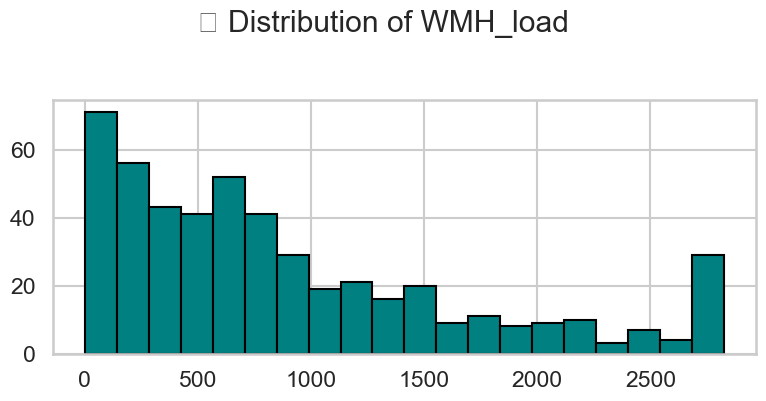

In [35]:
df['WMH_load'].hist(bins=20, figsize=(8, 4), color="teal", edgecolor="black")
plt.suptitle("📊 Distribution of WMH_load", y=1.02)
plt.tight_layout()
plt.show()

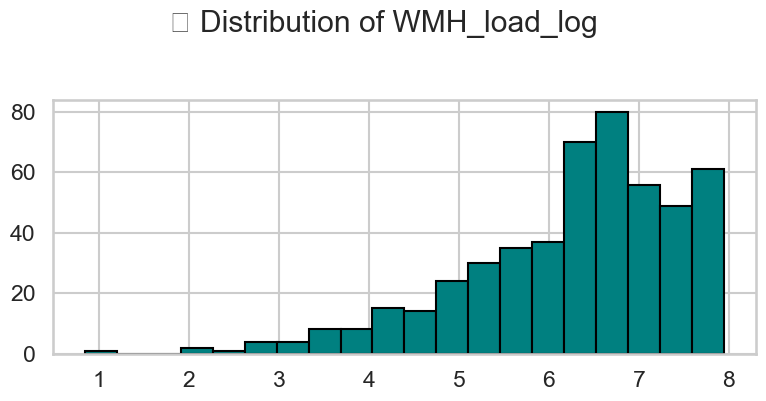

In [36]:
df['WMH_load_log'].hist(bins=20, figsize=(8, 4), color="teal", edgecolor="black")
plt.suptitle("📊 Distribution of WMH_load_log", y=1.02)
plt.tight_layout()
plt.show()

In [37]:
outlier_counts = iqr_outlier_summary(df, numerical_cols)
outlier_counts.head(15)

FA_mean                0
MD_mean                0
PSMD                   0
StreamlineCount_CCG    0
StreamlineCount_CST    0
FC_CST                 0
FD_CST                 0
FC_ANT                 0
FD_ANT                 0
WMH_load               0
Thalamus_Vol           0
Hippocampus_Vol        0
TractVol_CCG           0
TractVol_CST           0
TBSS_MD                0
dtype: int64

# 🔗 Correlation analysis

Many neuroimaging features measure related biological properties and can therefore be strongly correlated.

### Why this step matters

Correlation analysis helps us identify:
- redundancy among predictors
- biologically related feature groups
- duplicated or near-duplicated measurements
- risk of multicollinearity

For example, diffusion metrics such as FA, MD, RD, and AD often share partial information.

### Why this is important for future ML models

Highly correlated features can affect models in different ways:

- **Linear models** may become unstable
- **Coefficient interpretation** becomes difficult
- **Feature importance** may be spread across redundant predictors
- **Overfitting** may increase when many similar features are included

Later, we may address this using:
- feature selection
- dimensionality reduction (PCA)
- regularization (L1/L2)
- domain-informed feature grouping


In [38]:
corr_matrix = df[numerical_cols].corr()
corr_matrix.head()


,FA_mean,MD_mean,FD_fixel,FC_fixel,age,RD_mean,AD_mean,MK_mean,ODI,ODI.1,...,Thalamus_Vol,WMH_load,FD_ANT,FC_ANT,FD_CST,FC_CST,StreamlineCount_CST,StreamlineCount_CCG,PSMD,gFA
FA_mean,1.000000,-0.032794,0.018727,0.082215,0.007757,-0.034845,-0.027261,0.052932,0.030639,0.030639,...,-0.034853,-0.049283,0.023098,-0.046906,-0.016200,-0.034376,0.022650,0.021427,-0.040036,-0.015508
MD_mean,-0.032794,1.000000,0.072154,-0.058908,-0.021562,-0.011049,-0.006202,-0.073838,-0.023295,-0.023295,...,0.025577,0.103223,0.041779,0.047744,0.040247,-0.046535,-0.010248,0.025336,-0.094409,-0.068590
FD_fixel,0.018727,0.072154,1.000000,-0.051541,-0.030758,-0.043141,0.016252,0.017926,0.004305,0.004305,...,0.060666,0.050589,-0.003106,-0.032104,-0.005204,-0.051209,0.013282,0.043878,-0.040191,-0.012789
FC_fixel,0.082215,-0.058908,-0.051541,1.000000,0.020665,0.038690,0.007205,0.033856,0.055030,0.055030,...,-0.047884,-0.007602,0.020495,0.091400,-0.038434,0.012795,0.061145,-0.023053,0.072212,-0.027149
age,0.007757,-0.021562,-0.030758,0.020665,1.000000,0.092901,0.027136,-0.079891,-0.110699,-0.110699,...,0.031098,-0.010612,0.019843,0.024265,-0.005339,-0.011170,0.028743,-0.011170,0.040814,0.018504


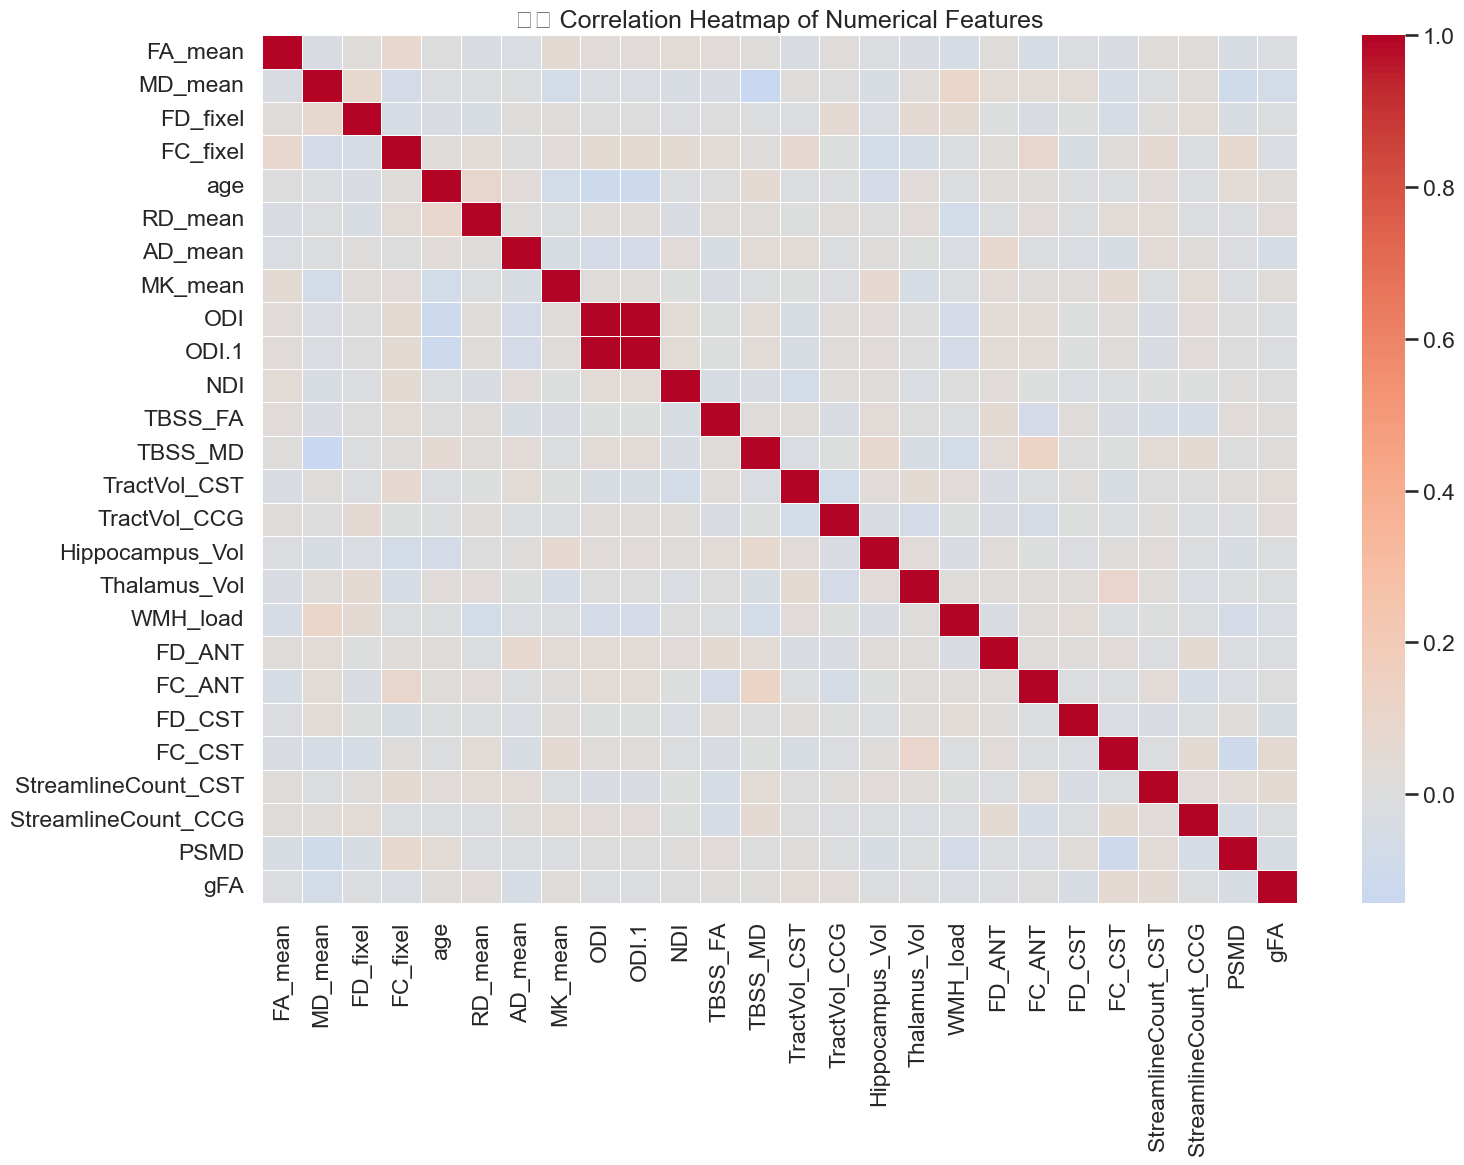

In [39]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("🌡️ Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


In [40]:
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_triangle.stack()
    .sort_values(key=lambda x: np.abs(x), ascending=False)
)

high_corr_pairs.head(20)


ODI           ODI.1              1.000000
MD_mean       TBSS_MD           -0.143784
TBSS_MD       FC_ANT             0.120490
age           ODI               -0.110699
              ODI.1             -0.110699
FC_CST        PSMD              -0.103990
MD_mean       WMH_load           0.103223
Thalamus_Vol  FC_CST             0.099838
MD_mean       PSMD              -0.094409
age           RD_mean            0.092901
FC_fixel      FC_ANT             0.091400
RD_mean       WMH_load          -0.083204
FA_mean       FC_fixel           0.082215
TractVol_CST  TractVol_CCG      -0.081865
age           MK_mean           -0.079891
AD_mean       FD_ANT             0.076002
FC_fixel      Hippocampus_Vol   -0.075733
MD_mean       MK_mean           -0.073838
FC_fixel      PSMD               0.072212
MD_mean       FD_fixel           0.072154
dtype: float64

## 💡 Interpretation

Very high correlations may occur between:
- related diffusion measures
- left/right or similar tract metrics
- repeated or derived measures

In later sessions, we may use:
- feature selection
- PCA
- regularization
- domain-informed pruning


# 🧪 Check suspicious or repeated columns

The dataset includes both:
- `ODI`
- `ODI.1`

This may indicate:
- a duplicated column
- a second version of the same metric
- a naming artifact during CSV export

If duplicate features are kept:
- they artificially increase feature redundancy
- they may bias feature importance estimates
- they may give some information disproportionate weight
- they may make the model appear more stable than it really is

This step helps ensure that the input space is clean and interpretable.

In [41]:
if "ODI" in df.columns and "ODI.1" in df.columns:
    same_values = df["ODI"].equals(df["ODI.1"])
    corr_odi = df[["ODI", "ODI.1"]].corr().iloc[0, 1]
    print("Are ODI and ODI.1 exactly identical?", same_values)
    print("Correlation between ODI and ODI.1:", corr_odi)
df=df.drop(columns='ODI.1')

Are ODI and ODI.1 exactly identical? True
Correlation between ODI and ODI.1: 1.0


# 🌟 Pairwise relationships among selected features

Pairplots help us visualize relationships between multiple features at once.

### Why this step matters

This allows us to inspect:
- linear or nonlinear relationships
- class separation in 2D projections
- clustering tendencies
- whether groups overlap heavily
- whether some variables track each other closely

### Why this is important for future ML models

Even before fitting a classifier, pairwise visualization gives intuition about:
- whether the task may be easy or difficult
- whether decision boundaries may need to be nonlinear
- whether some variables may be especially informative together

For instance:
- if classes overlap strongly in pairwise space, simple models may struggle
- if clusters are partially separated, more flexible models may help
- if one feature pair shows strong separation, those variables may be promising candidates


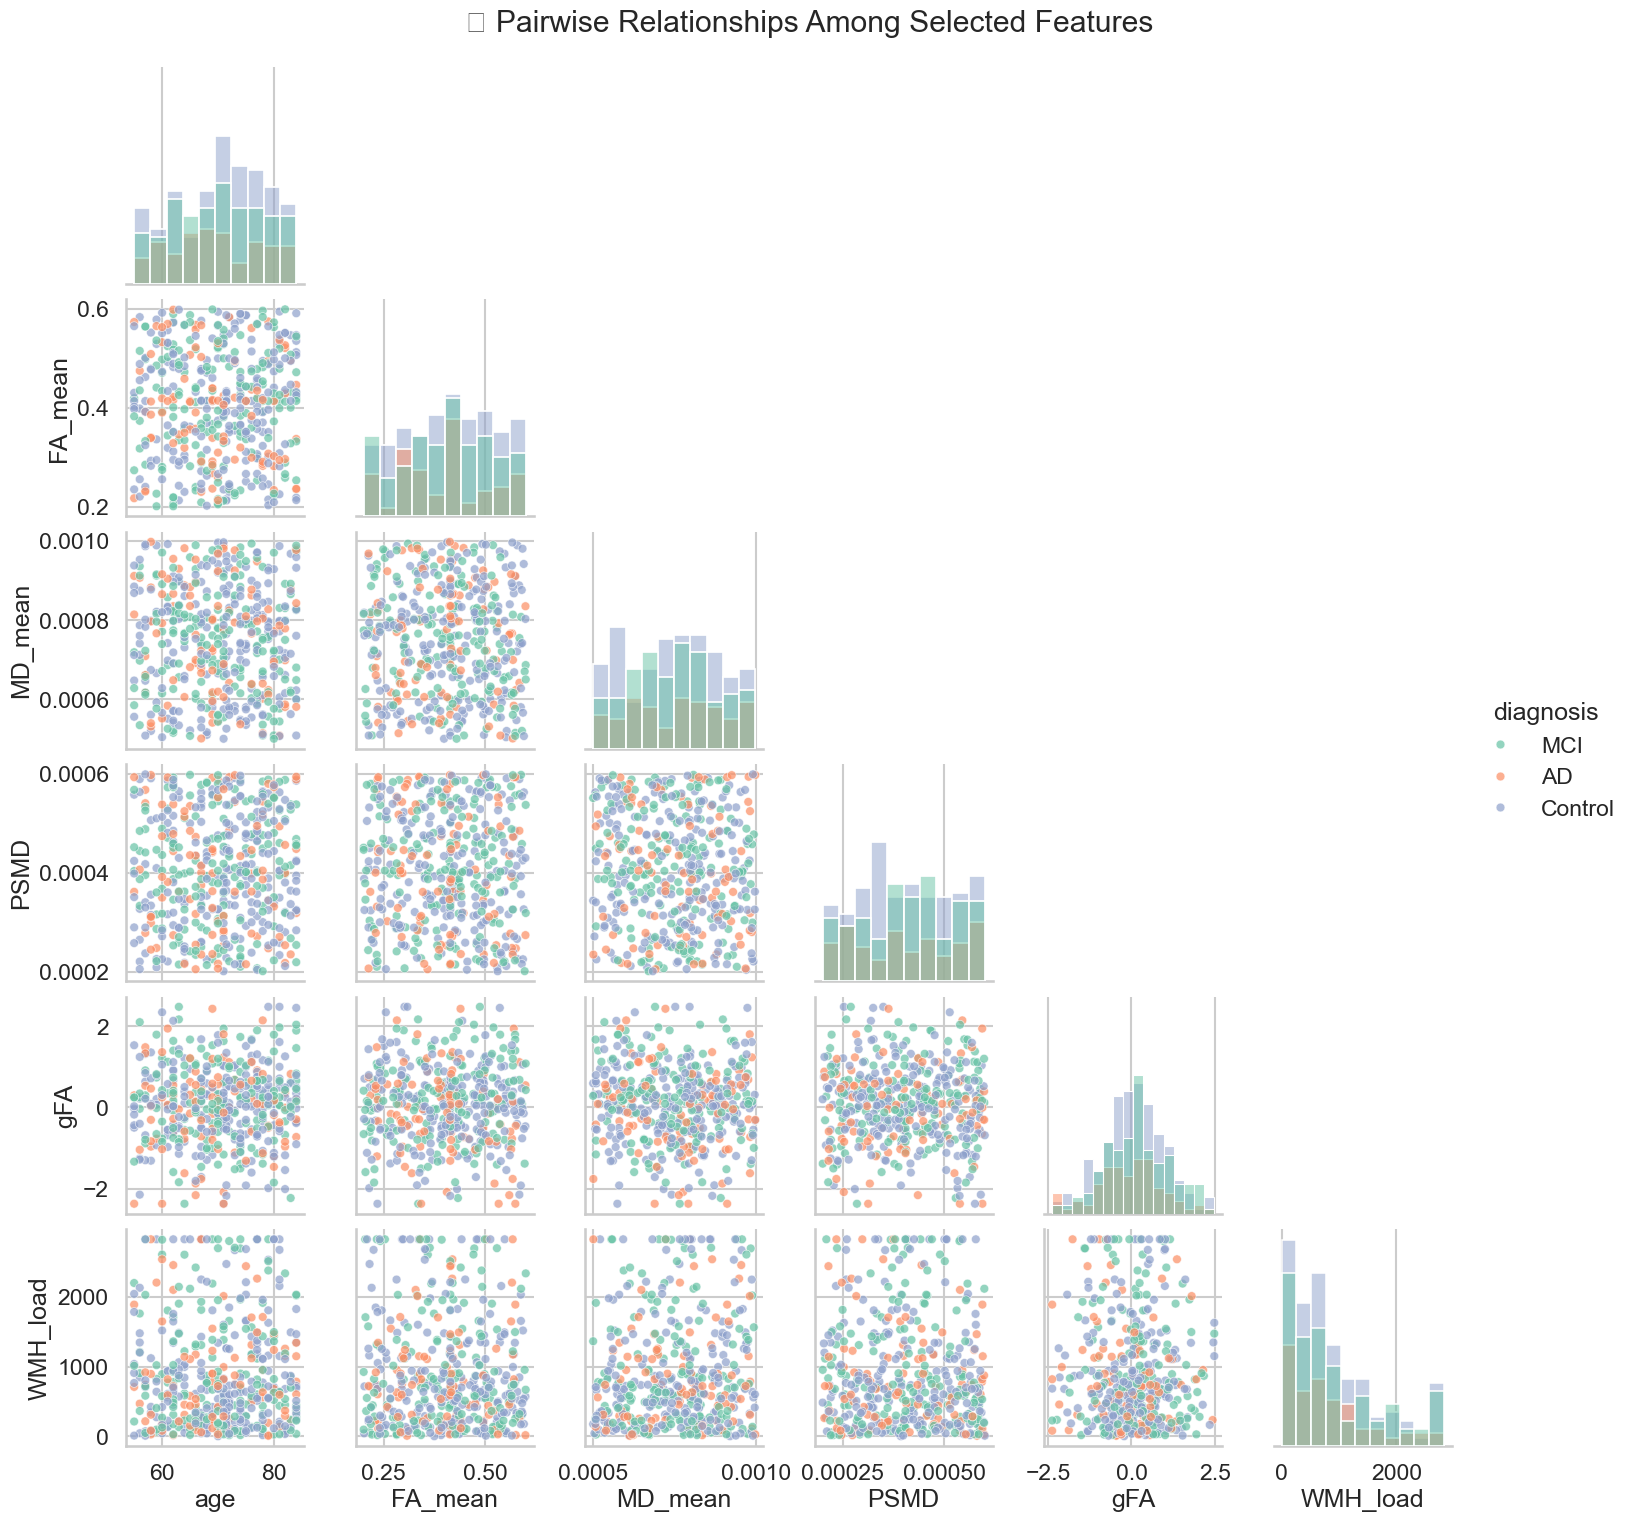

In [42]:
pairplot_features = ["age", "FA_mean", "MD_mean", "PSMD", "gFA", "WMH_load", "diagnosis"]
pairplot_features = [col for col in pairplot_features if col in df.columns]

sns.pairplot(
    df[pairplot_features].dropna(),
    hue="diagnosis",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.7, "s": 40}
)
plt.suptitle("🌟 Pairwise Relationships Among Selected Features", y=1.02)
plt.show()


# 🎭 Confounds in neuroimaging machine learning

A confound is a variable that is associated with both the predictors and the outcome.

### Why this step matters

Confounds can create misleading predictive patterns.  
The model may appear to predict the target, but in reality it may be exploiting a non-causal shortcut.

Common confounds in neuroimaging include:
- age
- sex
- site/scanner
- head motion
- intracranial volume
- acquisition protocol differences

### Why this is important for future ML models

If confounds are ignored:
- model performance may be inflated
- generalization to new cohorts may fail
- biological interpretation becomes weak
- the model may not be clinically trustworthy

This is especially important in medical AI, where we want the model to learn disease-relevant information rather than demographic or technical artifacts.


In [43]:
if "age" in numerical_cols:
    age_corr = corr_matrix["age"].sort_values(ascending=False)
    print(age_corr)


age                    1.000000
RD_mean                0.092901
TBSS_MD                0.059187
PSMD                   0.040814
Thalamus_Vol           0.031098
StreamlineCount_CST    0.028743
AD_mean                0.027136
FC_ANT                 0.024265
FC_fixel               0.020665
FD_ANT                 0.019843
gFA                    0.018504
TBSS_FA                0.007820
FA_mean                0.007757
FD_CST                -0.005339
WMH_load              -0.010612
FC_CST                -0.011170
StreamlineCount_CCG   -0.011170
TractVol_CCG          -0.012480
TractVol_CST          -0.020173
NDI                   -0.020930
MD_mean               -0.021562
FD_fixel              -0.030758
Hippocampus_Vol       -0.063097
MK_mean               -0.079891
ODI.1                 -0.110699
ODI                   -0.110699
Name: age, dtype: float64


If age is strongly associated with many imaging features, the model may partly rely on age-related variance.

Later solutions may include:
- including confounds explicitly
- residualization
- matched cohorts
- stratified sampling


If two columns are duplicates or nearly identical, we may keep only one to reduce redundancy.


# 🛠️ Prepare data for machine learning

## ___ Defining predictors and target

Now we explicitly separate:
- **X** → predictor variables
- **y** → target labels

We also remove `subject_id`, because it is an identifier rather than a biological feature.

### Why this step matters

A machine learning model should learn from meaningful predictors, not from administrative identifiers.

Subject IDs are not scientifically informative and can even become dangerous if they allow the model to memorize hidden structure.

### Why this is important for future ML models

Separating predictors and target is the core setup for supervised learning.

This step ensures:
- the model is trained on valid inputs
- the target is clearly defined
- leakage from label-related columns is avoided
- preprocessing can be applied only to predictors

This is also where we think carefully about the prediction task:
- multiclass classification?
- binary classification?
- regression?



In [44]:
df_model = df.copy()

# Drop rows with missing diagnosis
df_model = df_model.dropna(subset=["diagnosis"])

# Define target and predictors
target_col = "diagnosis"
id_col = "subject_id"

X = df_model.drop(columns=[target_col, id_col], errors="ignore")
y = df_model[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (499, 26)
y shape: (499,)


In [45]:
print("Target classes:")
print(y.value_counts())


Target classes:
diagnosis
Control    227
MCI        177
AD          95
Name: count, dtype: int64


# 🏷️ Encoding class labels

Most machine learning algorithms require target labels in numerical form.

### Why this step matters

Human-readable labels like:
- AD
- MCI
- Control

are useful for interpretation, but many models expect encoded labels such as:
- 0
- 1
- 2

### Why this is important for future ML models

Encoding labels is necessary for:
- classifier training
- confusion matrix construction
- probability estimation
- metric calculation

It also ensures consistency between:
- training labels
- predicted outputs
- decoded interpretations later

We should always keep track of the mapping between encoded values and original class names.


In [46]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded labels (first 10):", y_encoded[:10])


Classes: ['AD' 'Control' 'MCI']
Encoded labels (first 10): [2 2 0 1 0 1 1 2 2 2]


# ✂️ Train/test split

Before fitting any preprocessing or model, we divide the data into training and test sets.

### Why this step matters

The training set is used to:
- learn preprocessing parameters
- train the model

The test set is used only once at the end to estimate generalization performance.

This simulates the real-world scenario of applying the model to unseen data.

### Why this is important for future ML models

Without a proper train/test split:
- we cannot assess generalization honestly
- performance estimates become overly optimistic
- preprocessing may accidentally incorporate future information

Using **stratified splitting** is particularly important in classification because it preserves the class proportions in both training and test sets.


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (399, 26)
Test set: (100, 26)


# 🧰 Building a preprocessing pipeline

We now create a pipeline that:
1. imputes missing numerical values
2. scales numerical features

### Why this step matters

This makes preprocessing:
- organized
- reproducible
- less error-prone
- compatible with later modeling steps

A pipeline also guarantees that the same transformations learned from the training set are applied consistently to the test set.

### Why this is important for future ML models

Many ML algorithms assume:
- no missing values
- comparable feature scales

This is especially important for:
- logistic regression
- SVM
- k-nearest neighbors
- neural networks

Pipelines also make it much easier to later combine preprocessing with:
- cross-validation
- hyperparameter tuning
- model comparison


In [48]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_processed = preprocessing_pipeline.fit_transform(X_train[numeric_features])
X_test_processed = preprocessing_pipeline.transform(X_test[numeric_features])

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed training shape: (399, 26)
Processed test shape: (100, 26)


# ⚙️ Feature scaling

Feature scaling transforms variables so that they are on a comparable scale, often with mean 0 and standard deviation 1.

### Why this step matters

In this dataset, some variables may be:
- small decimal diffusion metrics
- large volumetric measurements
- count-based tract variables

Without scaling, variables with larger numeric ranges may dominate the optimization process.

### Why this is important for future ML models

Scaling is crucial for models that depend on:
- distances
- dot products
- gradient optimization
- coefficient regularization

Examples:
- SVM
- logistic regression
- k-NN
- PCA
- neural networks

Scaling often has less impact on tree-based methods, but it is still good practice when comparing multiple algorithms in a common workflow.


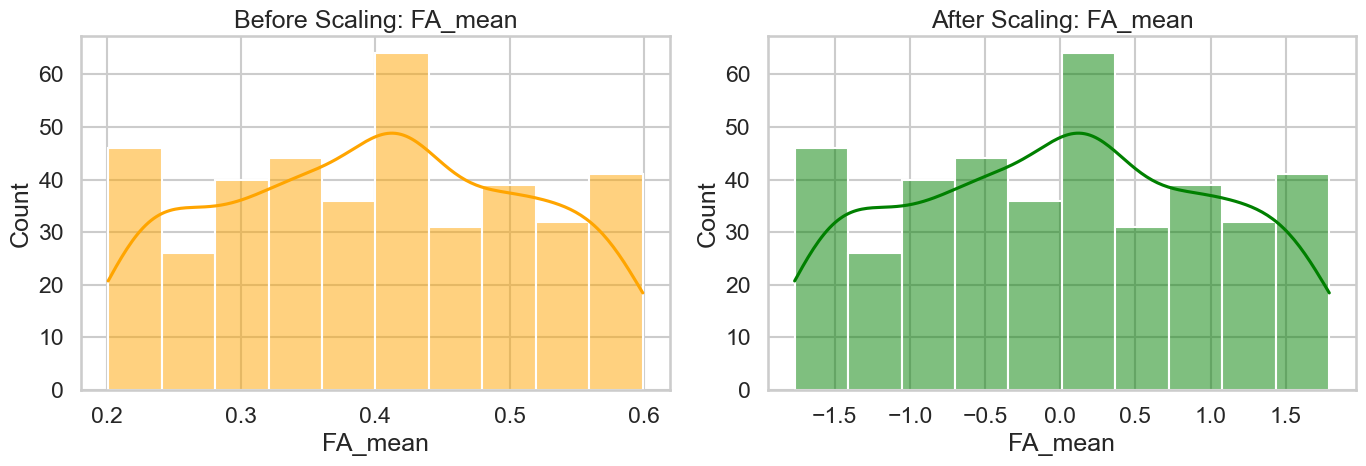

In [49]:
X_train_processed_df = pd.DataFrame(X_train_processed, columns=numeric_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train[numeric_features].iloc[:, 0].dropna(), kde=True, ax=axes[0], color="orange")
axes[0].set_title(f"Before Scaling: {numeric_features[0]}")

sns.histplot(X_train_processed_df.iloc[:, 0], kde=True, ax=axes[1], color="green")
axes[1].set_title(f"After Scaling: {numeric_features[0]}")

plt.tight_layout()
plt.show()


Scaling is especially important for models such as:
- logistic regression
- SVM
- k-nearest neighbors
- neural networks

Tree-based models are usually less sensitive to scaling.


# 🚫 Data leakage

Data leakage happens when information from outside the training set influences the training process.

### Why this step matters

Leakage is one of the most common and most harmful mistakes in machine learning.

It often happens silently, for example when:
- imputing before splitting
- scaling before splitting
- selecting features using all samples
- tuning hyperparameters on the test set
- including variables that directly reveal the target

### Why this is important for future ML models

Leakage can produce:
- unrealistically high test accuracy
- poor generalization in real-world settings
- incorrect scientific conclusions
- overconfidence in a model that is not actually robust

In medical and neuroimaging applications, leakage is especially dangerous because it can make a model seem clinically useful when it is not.

This is why we emphasize:
**split first, fit preprocessing on training only, then evaluate on unseen data.**


In [50]:
# ❌ Wrong approach (example only — do not use)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X_all_wrong = X.copy()

imputer_wrong = SimpleImputer(strategy="median")
scaler_wrong = StandardScaler()

X_all_wrong_imputed = imputer_wrong.fit_transform(X_all_wrong)
X_all_wrong_scaled = scaler_wrong.fit_transform(X_all_wrong_imputed)

print("This is leakage because preprocessing was fit on the full dataset.")


This is leakage because preprocessing was fit on the full dataset.


# ✅ Correct approach

Correct workflow:

1. Split data

2. Fit preprocessing on training set only

3. Transform training and test sets


# 🧠 Key takeaways from this session

This session introduced the essential early stages of a neuroimaging ML workflow.

We learned that good machine learning starts with good data understanding.

### What we achieved

We:
- loaded the dataset correctly
- inspected structure and types
- cleaned diagnosis labels
- examined missing values
- visualized distributions
- identified possible outliers
- explored feature correlations
- considered confounds
- built a leakage-safe preprocessing workflow

### Why this matters for future sessions

In later sessions, we will move from data preparation to actual predictive modeling.

Everything we do next — classifier training, model tuning, cross-validation, and interpretation — depends on the quality of the workflow we established here.

This session is the bridge between:
- raw neuroimaging-derived features
and
- reproducible machine learning analysis


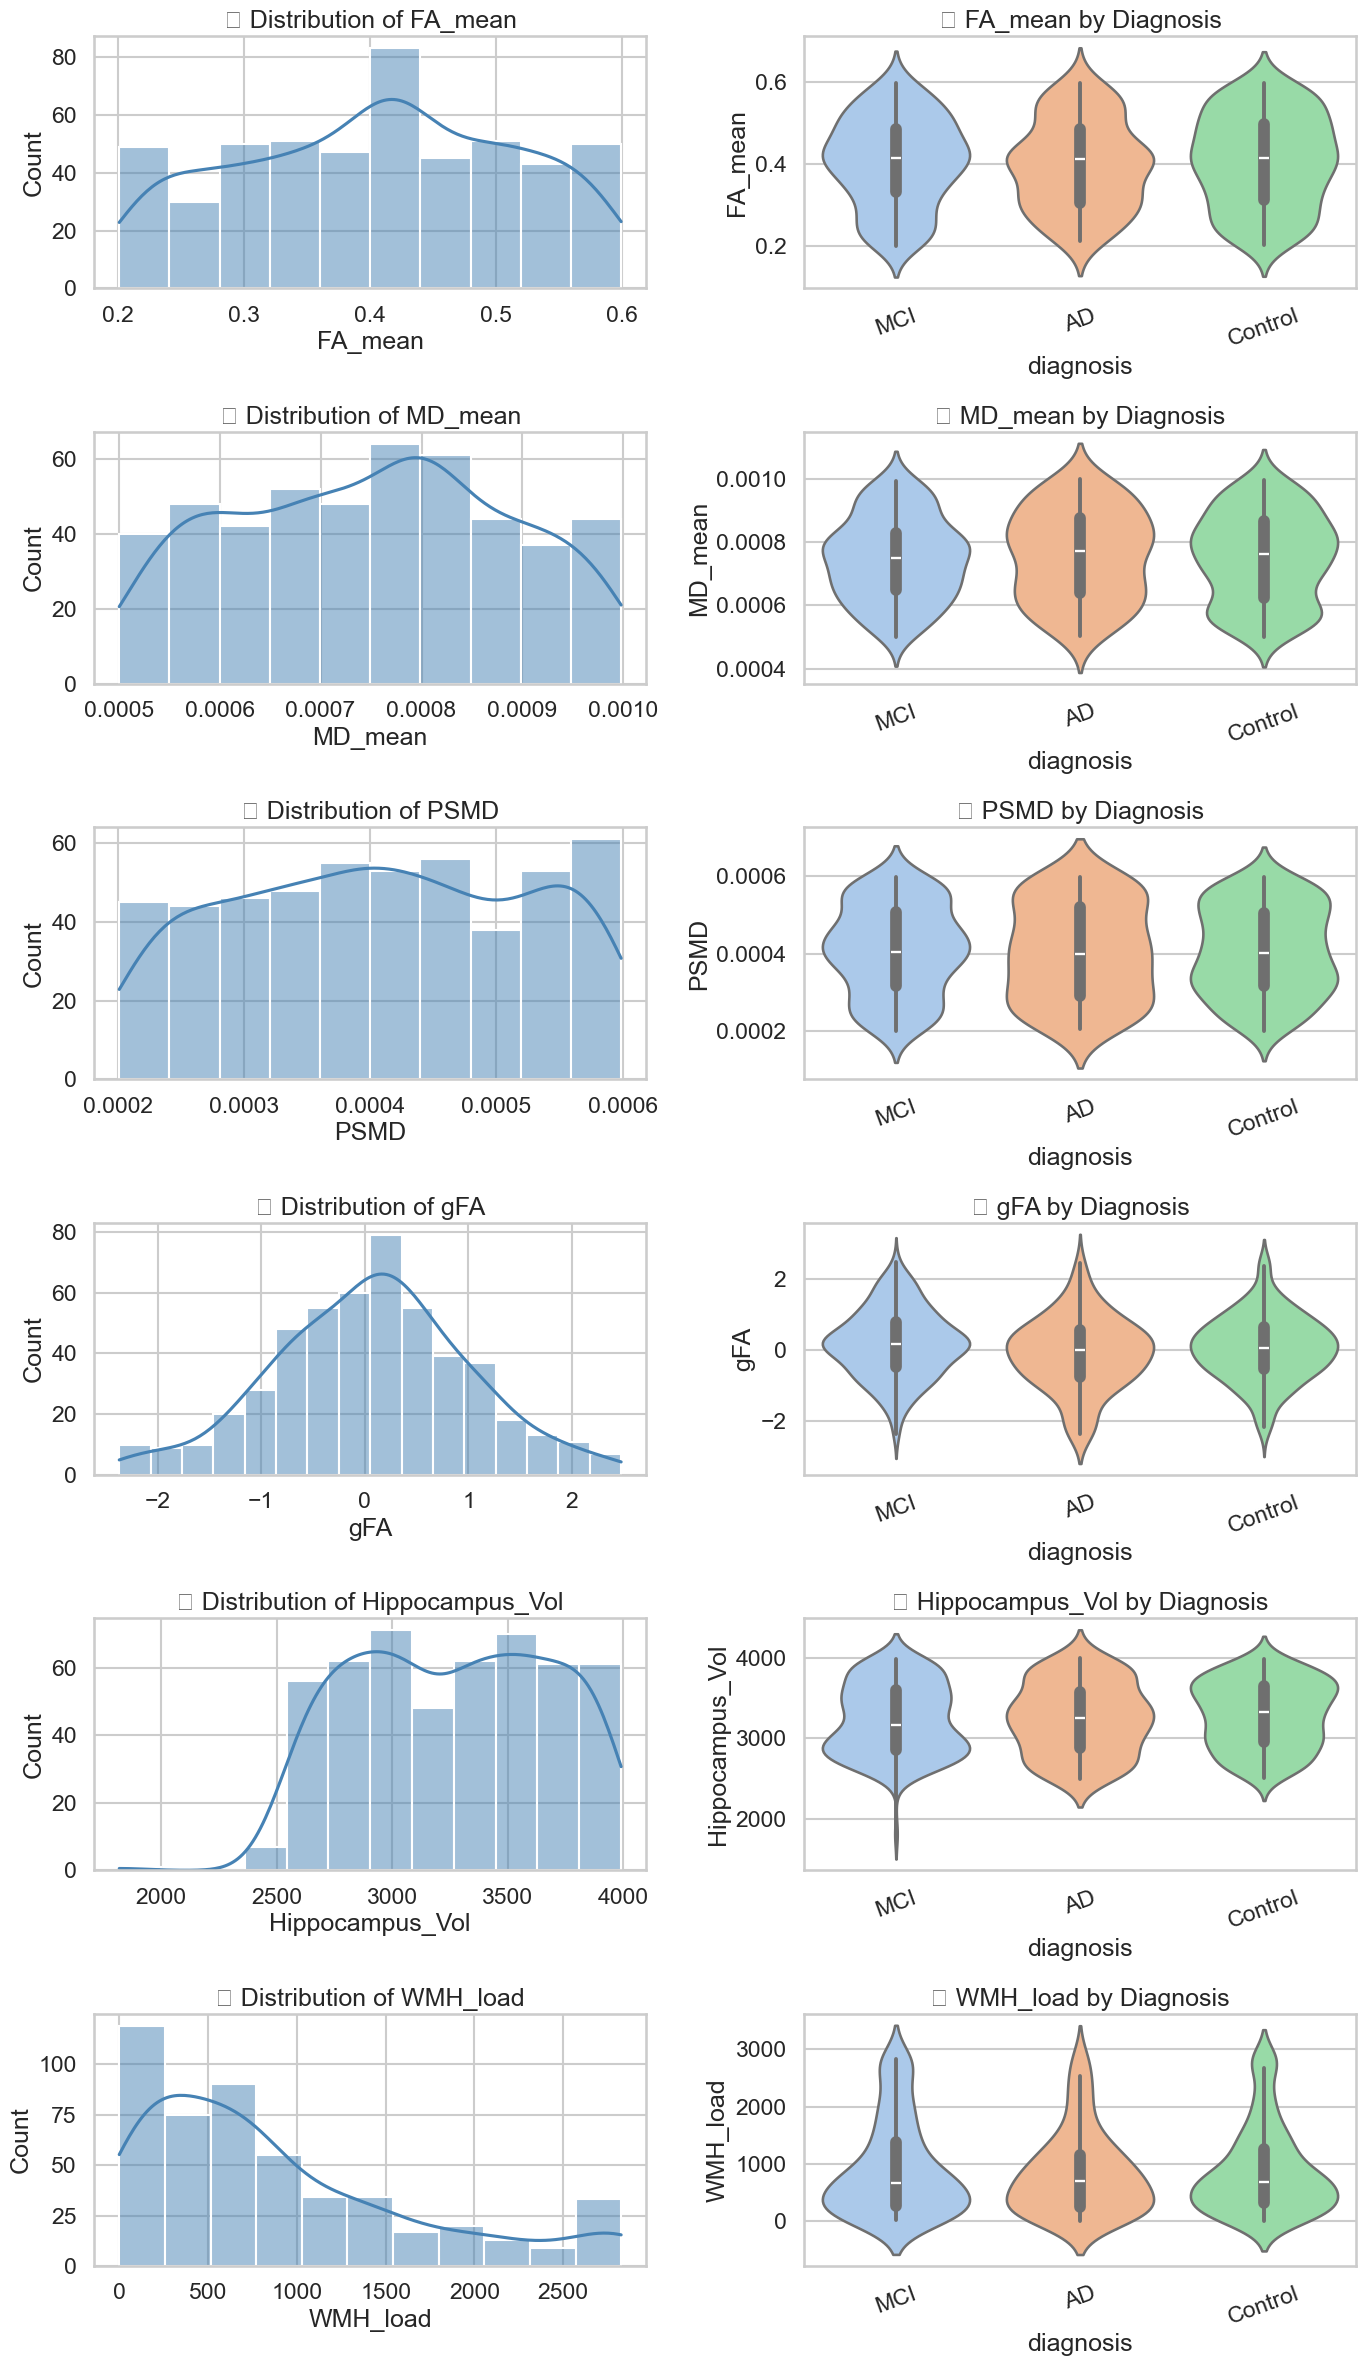

In [51]:
selected_features = ["FA_mean", "MD_mean", "PSMD", "gFA", "Hippocampus_Vol", "WMH_load"]
selected_features = [col for col in selected_features if col in df.columns]

fig, axes = plt.subplots(len(selected_features), 2, figsize=(14, 4 * len(selected_features)))

for i, feat in enumerate(selected_features):
    sns.histplot(df[feat], kde=True, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"📊 Distribution of {feat}")

    sns.violinplot(data=df, x="diagnosis", y=feat, ax=axes[i, 1], palette="pastel")
    axes[i, 1].set_title(f"🎻 {feat} by Diagnosis")
    axes[i, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
